In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import sys
import os
import pickle
from IPython.display import Audio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
import keras
%matplotlib inline
from keras import layers
import librosa
import csv

In [107]:
# The path to the dataset used (change with yours)
csv_path = 'C:/Users/stefa/OneDrive/Desktop/Proiect_PSV/PSV_proiect_StirbuStefan/02_Code&Data/features_3_sec.csv'
#csv_path = 'C:/Users/stefa/OneDrive/Desktop/Proiect_PSV/PSV_proiect_StirbuStefan/02_Code&Data/features_30_sec.csv'
# Reading the dataset using pandas
df = pd.read_csv(csv_path)

# Checking that the dataset is correctly read
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [108]:
print(f"Shape of the dataset is: {df.shape}")

Shape of the dataset is: (9990, 60)


In [109]:
df.dtypes

filename                    object
length                       int64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
harmony_mean               float64
harmony_var                float64
perceptr_mean              float64
perceptr_var               float64
tempo                      float64
mfcc1_mean                 float64
mfcc1_var                  float64
mfcc2_mean                 float64
mfcc2_var                  float64
mfcc3_mean                 float64
mfcc3_var                  float64
mfcc4_mean                 float64
mfcc4_var                  float64
mfcc5_mean                 float64
mfcc5_var           

In [110]:
# Removing the column 'filename' from the dataframe
df = df.drop(columns=['filename'],axis=1)

In [111]:
# Selecting the last column of the dataframe, corresponding to the list of genres
genre_list = df.iloc[:, -1]
encoder = LabelEncoder()

In [112]:
# Creating a list containing the names of the genres - used as labels for confusion matrix
set_genres = set()
labels_genres = []


for genre in genre_list:
    if genre not in set_genres:
        labels_genres.append(genre)
        set_genres.add(genre)

print(labels_genres)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [113]:
print(labels_genres)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [114]:
# Encoding the list of genres as values
y = encoder.fit_transform(genre_list)

In [115]:
encoded_set_genres = set()
encoded_labels_genres = []


for code in y:
    if code not in encoded_set_genres:
        encoded_labels_genres.append(code)
        encoded_set_genres.add(code)

print(encoded_labels_genres)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [116]:
genre_label_dict = dict(zip(encoded_labels_genres,labels_genres))
print(genre_label_dict)

{0: 'blues', 1: 'classical', 2: 'country', 3: 'disco', 4: 'hiphop', 5: 'jazz', 6: 'metal', 7: 'pop', 8: 'reggae', 9: 'rock'}


In [117]:
# Checking encoded list of genres
print(y)

[0 0 0 ... 9 9 9]


In [118]:
# Scaling all the columns except the last one of the dataframe
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(np.array(df.iloc[:, :-1], dtype = float))

In [119]:
# Splitting the data frame into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [120]:
print(X_train)

[[ 0.          0.27540815 -0.70601561 ... -0.64573602 -0.60125742
  -0.77952979]
 [ 0.         -0.48769616  1.97270536 ...  0.97508778  2.35544105
  -0.32587734]
 [ 0.         -0.23964216  1.01953737 ... -0.33550805 -0.02542302
   0.23005769]
 ...
 [ 0.          1.0968433   0.30519895 ...  0.68174806  0.4740378
   0.05584277]
 [ 0.          0.13680618  0.20523998 ... -0.40261862  0.51467806
  -0.04859314]
 [ 0.         -0.8802262   0.46193645 ...  2.0369974  -1.5232085
   1.69232386]]


In [121]:
print(f"The shape of X_train is {X_train.shape}")
print(f"The shape of y_train is {y_train.shape}")
print(f"The shape of X_test is {X_test.shape}")
print(f"The shape of y_test is {y_test.shape}")

The shape of X_train is (6693, 58)
The shape of y_train is (6693,)
The shape of X_test is (3297, 58)
The shape of y_test is (3297,)


In [122]:
from keras.models import Sequential
from keras.layers import Dense, Input

# Sequential model creation
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))  # Input layer with dimension equal to training set shape
model.add(Dense(256, activation='relu'))  # 1st Dense layer with dimension 256 and ReLU activation function
model.add(Dense(128, activation='relu'))  # 2nd Dense layer with dimension 128 and ReLU activation function
model.add(Dense(64, activation='relu'))  # 3rd Dense layer with dimension 64 and ReLU activation function
model.add(Dense(10, activation='softmax'))  # 4th Dense layer with dimension 10 (=number of genres) and Softmax activation function (used as output for classification)
# Compiling the created model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3058 - loss: 2.0064 - val_accuracy: 0.5678 - val_loss: 1.2678
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5976 - loss: 1.1727 - val_accuracy: 0.6776 - val_loss: 0.9787
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6876 - loss: 0.9099 - val_accuracy: 0.7267 - val_loss: 0.8252
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7378 - loss: 0.7574 - val_accuracy: 0.7498 - val_loss: 0.7401
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7853 - loss: 0.6518 - val_accuracy: 0.7677 - val_loss: 0.6812
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8238 - loss: 0.5540 - val_accuracy: 0.7871 - val_loss: 0.6305
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8456 - loss: 0.4923 - val_accuracy: 0.7913 - val_loss: 0.6182
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8604 - loss: 0.4488 - val_accuracy: 0.8071 - v

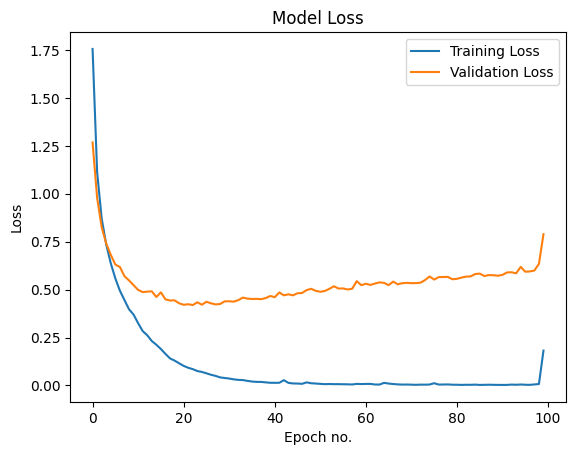

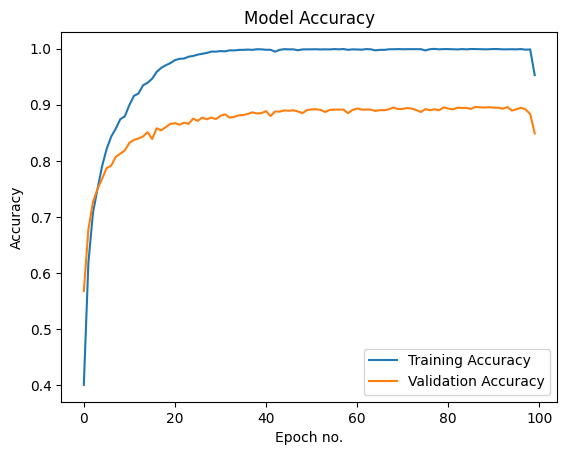

In [123]:
# Training the model and plotting the model accuracy and the model loss
progress = model.fit(X_train, y_train,
                    epochs=100,
                    batch_size=256,
                    validation_data=(X_test, y_test))

plt.plot(progress.history['loss'], label='Training Loss')
plt.plot(progress.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch no.')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot(progress.history['accuracy'], label='Training Accuracy')
plt.plot(progress.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch no.')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [124]:
test_loss, test_acc  = model.evaluate(X_test, y_test, batch_size=256)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8517 - loss: 0.7938 


In [125]:
print("The test loss is :",test_loss, "\nThe test accuracy is :",test_acc)

The test loss is : 0.7891681790351868 
The test accuracy is : 0.8489536046981812


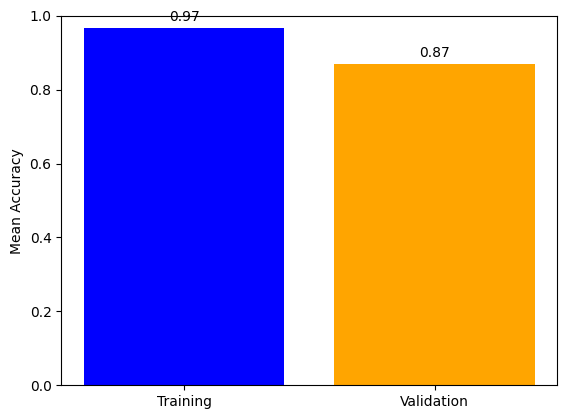

In [126]:
# The final accuracy values obtained
#train_accuracy = progress.history['accuracy'][-1]
#val_accuracy = progress.history['val_accuracy'][-1]

mean_train_accuracy = np.mean(progress.history['accuracy'])
mean_val_accuracy = np.mean(progress.history['val_accuracy'])

labels = ['Training', 'Validation']
values = [mean_train_accuracy, mean_val_accuracy]  # Accuracy values obtained

fig, ax = plt.subplots()
bars = ax.bar(labels, values, color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom')


plt.ylim(0, 1)  # Accuracy = [0, 1]
plt.ylabel('Mean Accuracy')
plt.show()

In [127]:
# Saving the trained model (for future re-use)
model_name = 'final_model_256.h5'
model.save(model_name)

In [128]:
# Loading trained model data
model_name = 'final_model_256.h5'
model_reloaded = keras.models.load_model(model_name)
keras.utils.plot_model(model_reloaded, to_file='model_test.png', show_shapes=True,show_dtype=True, show_layer_activations=True)
model_reloaded.summary()
predictions = model_reloaded.predict(X_test[:10])
predicted_classes = tf.argmax(predictions, axis=1)

# Printing predictions made
for i, pred in enumerate(predicted_classes):
    print(f"Sample {i + 1}: Predicted class = {pred.numpy()}")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        15,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,908 (222.30 KB)

 Trainable params: 56,906 (222.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Sample 1: Predicted class = 4
Sample 2: Predicted class = 2
Sample 3: Predicted class = 3
Sample 4: Predicted class = 2
Sample 5: Predicted class = 9
Sample 6: Predicted class = 9
Sample 7: Predicted class = 1
Sample 8: Predicted class = 2
Sample 9: Predicted class = 7
Sample 10: Predicted class = 4


104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


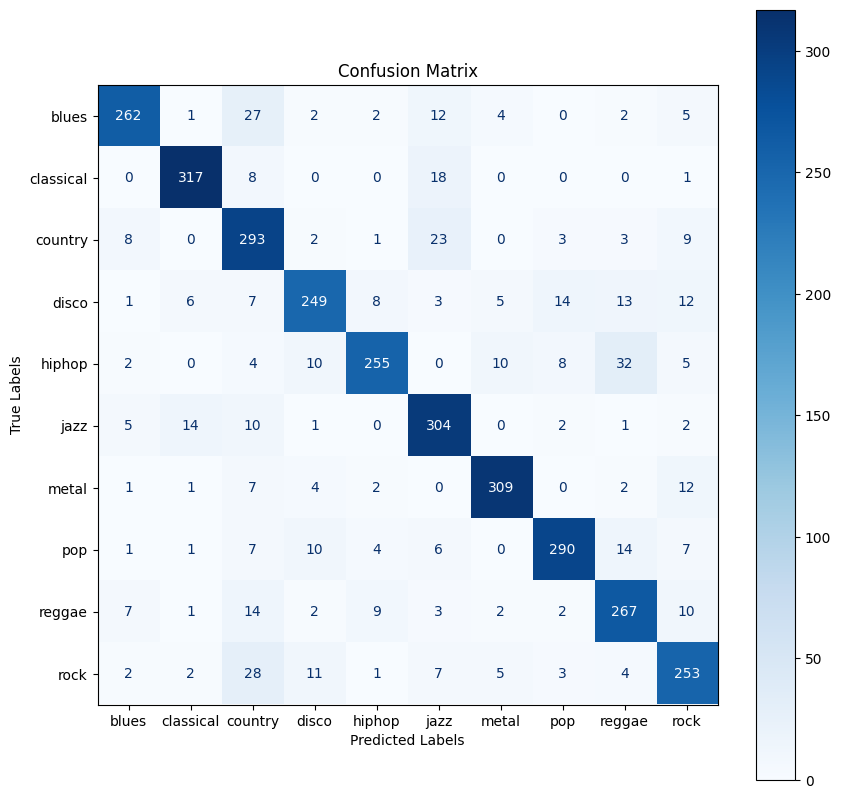

In [129]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Obtaining the model predictions for the testing set
y_pred = model_reloaded.predict(X_test)
y_pred_classes = tf.argmax(y_pred, axis=1).numpy()

# Confusion matrix calculation
cm = confusion_matrix(y_test, y_pred_classes)

# Plotting the obtained confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_genres)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [130]:
#### TESTING WITH OTHER SONGS (downloaded and saved in current folder)
#### Names of the song will be stored in a txt file and with a for-loop will
#### extract the features of every song based on their name-path

In [131]:
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Length of the audio
    length = librosa.get_duration(y=y, sr=sr)

    # Chromagram
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma_stft_mean = np.mean(chroma_stft)
    chroma_stft_var = np.var(chroma_stft)

    # Root Mean Square Energy
    rms = librosa.feature.rms(y=y)
    rms_mean = np.mean(rms)
    rms_var = np.var(rms)

    # Spectral Centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    spectral_centroid_mean = np.mean(spectral_centroid)
    spectral_centroid_var = np.var(spectral_centroid)

    # Spectral Bandwidth
    spectral_bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    spectral_bandwidth_mean = np.mean(spectral_bandwidth)
    spectral_bandwidth_var = np.var(spectral_bandwidth)

    # Spectral Rolloff
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rolloff_mean = np.mean(rolloff)
    rolloff_var = np.var(rolloff)

    # Zero Crossing Rate
    zero_crossing_rate = librosa.feature.zero_crossing_rate(y)
    zero_crossing_rate_mean = np.mean(zero_crossing_rate)
    zero_crossing_rate_var = np.var(zero_crossing_rate)

    # Harmonics and Perceived Noise
    harmony, perceptr = librosa.effects.hpss(y)
    harmony_mean = np.mean(harmony)
    harmony_var = np.var(harmony)
    perceptr_mean = np.mean(perceptr)
    perceptr_var = np.var(perceptr)

    # Tempo
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr)[0]

    # MFCCs
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mfccs_means = np.mean(mfccs, axis=1)
    mfccs_vars = np.var(mfccs, axis=1)

    # Create the feature list
    features = [
        length,
        chroma_stft_mean, chroma_stft_var,
        rms_mean, rms_var,
        spectral_centroid_mean, spectral_centroid_var,
        spectral_bandwidth_mean, spectral_bandwidth_var,
        rolloff_mean, rolloff_var,
        zero_crossing_rate_mean, zero_crossing_rate_var,
        harmony_mean, harmony_var,
        perceptr_mean, perceptr_var,
        tempo
    ] + list(mfccs_means) + list(mfccs_vars)

    return features

In [132]:
header = [
    "length", "chroma_stft_mean", "chroma_stft_var", "rms_mean", "rms_var",
    "spectral_centroid_mean", "spectral_centroid_var", "spectral_bandwidth_mean", "spectral_bandwidth_var",
    "rolloff_mean", "rolloff_var", "zero_crossing_rate_mean", "zero_crossing_rate_var", "harmony_mean",
    "harmony_var", "perceptr_mean", "perceptr_var", "tempo"
] + [f"mfcc{i+1}_mean" for i in range(20)] + [f"mfcc{i+1}_var" for i in range(20)]

with open('testare.csv', 'w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(header)

In [133]:
song_names = []
file = open("song_names.txt", "r")
while True:
	content=file.readline()
	if not content:
		break
	song_names.append(content.rstrip())
file.close()

In [134]:
song_names

['Metallica_sad_but_true.mp3',
 'Metallica_Dream_No_More.mp3',
 'Metallica_Crown_of_Barbed_Wire.mp3',
 'Avenged_Sevenfold_The_Stage.mp3',
 'Blake_Shelton_Gods_Country.mp3',
 'Gary_BB_Coleman_The_Sky_is_Crying.mp3',
 'Korn_Cold.mp3',
 'Lutan_Fyah_Rasta_Reggae_Music.mp3']

In [135]:
with open('testare.csv', 'a+', newline='') as file:
    writer = csv.writer(file)
    for i in song_names:
        features = extract_features(i)
        writer.writerow(features)
    

C:\Users\stefa\AppData\Local\Temp\ipykernel_16408\4292711618.py:46: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr)[0]


In [136]:
df1 = pd.read_csv('testare.csv')

In [137]:
df1.dtypes

length                     float64
chroma_stft_mean           float64
chroma_stft_var            float64
rms_mean                   float64
rms_var                    float64
spectral_centroid_mean     float64
spectral_centroid_var      float64
spectral_bandwidth_mean    float64
spectral_bandwidth_var     float64
rolloff_mean               float64
rolloff_var                float64
zero_crossing_rate_mean    float64
zero_crossing_rate_var     float64
harmony_mean               float64
harmony_var                float64
perceptr_mean              float64
perceptr_var               float64
tempo                      float64
mfcc1_mean                 float64
mfcc2_mean                 float64
mfcc3_mean                 float64
mfcc4_mean                 float64
mfcc5_mean                 float64
mfcc6_mean                 float64
mfcc7_mean                 float64
mfcc8_mean                 float64
mfcc9_mean                 float64
mfcc10_mean                float64
mfcc11_mean         

In [138]:
TEST = scaler.fit_transform(np.array(df1, dtype = float))

In [139]:
TEST_predictions = model_reloaded.predict(TEST)
TEST_predictions_classes = tf.argmax(TEST_predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [140]:
for i, pred in enumerate(TEST_predictions_classes):
    print(f"Sample {i + 1}: Predicted class = {genre_label_dict.get(pred.numpy())}")

Sample 1: Predicted class = rock
Sample 2: Predicted class = disco
Sample 3: Predicted class = rock
Sample 4: Predicted class = jazz
Sample 5: Predicted class = blues
Sample 6: Predicted class = jazz
Sample 7: Predicted class = disco
Sample 8: Predicted class = jazz
